# 📘 Lecture 5 — Additional Exercises (trang 35–39)
## Lời giải step by step + Python thực hành trên Google Colab

**Tài liệu gốc:** `lect5_26.pdf`, *Machine Learning: Statistical Approach — Lecture 5: Generalization, Model Selection and Regularization*, Can Van Hao.

**Mục tiêu:** hiểu và giải bốn bài Additional Exercise có trong các trang 35, 37, 38, 39. Trang 36 bổ sung lý thuyết K-fold Cross-validation nên cũng có một ví dụ nhỏ.

| Trang | Nội dung | Kỹ năng |
|---|---|---|
| 35 | Bias–variance decomposition | Bình phương tổng, kỳ vọng, triệt tiêu tích chéo |
| 36 | Chọn số folds $K$ | Hiểu CV, số mẫu train/validation |
| 37 | Lasso — soft thresholding | Đạo hàm theo từng trường hợp, điểm không khả vi |
| 38 | Ridge là Gaussian MAP | Likelihood, prior, posterior, cực tiểu |
| 39 | Separated logistic + ridge | Đạo hàm sigmoid, nghiệm hữu hạn, tính lõm |

**Cách chạy trong Colab:** `File → Upload notebook` → chọn file `.ipynb` này → `Runtime → Run all`. Không cần tải bộ dữ liệu nào và không cần cài thêm thư viện trong Colab.

> Phần chứng minh và câu hỏi bám sát slide. Các ví dụ số và biểu đồ Python là phần **minh họa bổ sung**, không phải dữ liệu cho sẵn trong đề.

## 0. Chuẩn bị môi trường

Dùng các thư viện phổ biến có sẵn trong Colab: `numpy`, `matplotlib`, `scipy`. Đặt seed cố định để bạn chạy lại vẫn thu được kết quả như nhau.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, brentq

rng = np.random.default_rng(42)
np.set_printoptions(precision=5, suppress=True)
print("Sẵn sàng! NumPy:", np.__version__)

Sẵn sàng! NumPy: 2.3.5


---
# 1. Trang 35 — Bias–Variance Decomposition

### 1.1. Phân tích đề

Tại một đầu vào cố định $x$, quan sát mới thỏa mãn:

$$Y=f_0(x)+\varepsilon,\qquad E[\varepsilon\mid X=x]=0,\qquad \operatorname{Var}(\varepsilon\mid X=x)=\sigma^2.$$

$D$ là tập dữ liệu huấn luyện ngẫu nhiên; thuật toán học từ $D$ tạo ra $\hat f_D(x)$. Ta giả sử **nhiễu của quan sát mới độc lập với tập training**.

Đề yêu cầu chứng minh:

$$\boxed{E_{D,\varepsilon}[(Y-\hat f_D(x))^2\mid X=x]=\sigma^2+\operatorname{Bias}(x)^2+\operatorname{Var}_D(\hat f_D(x)).}$$

Đây là một đẳng thức về **kỳ vọng sai số trên những lần lấy mẫu dữ liệu mới**, không phải công thức nói rằng mọi sai số của một lần dự đoán đều bằng tổng ba số đó.

### 1.2. Bước 1 — Cộng và trừ kỳ vọng của mô hình

Đặt $m(x)=E_D[\hat f_D(x)]$. Khi đó:

$$\begin{aligned}
Y-\hat f_D(x)
&=f_0(x)+\varepsilon-\hat f_D(x)\\
&=\varepsilon+\underbrace{\big[f_0(x)-m(x)\big]}_{A}
+\underbrace{\big[m(x)-\hat f_D(x)\big]}_{B}.
\end{aligned}$$

- $A$ **không ngẫu nhiên** khi đã cố định $x$ (vì lấy kỳ vọng theo $D$).
- $E_D[B]=m(x)-E_D[\hat f_D(x)]=0$.

### 1.3. Bước 2 — Bình phương

$$\begin{aligned}
(Y-\hat f_D(x))^2
&=(\varepsilon+A+B)^2\\
&=\varepsilon^2+A^2+B^2+2\varepsilon A+2\varepsilon B+2AB.
\end{aligned}$$

### 1.4. Bước 3 — Vì sao các tích chéo biến mất?

- $E[\varepsilon A]=A E[\varepsilon]=0$ vì kỳ vọng của nhiễu bằng $0$.
- $E[AB]=A E_D[B]=0$ vì $E_D[B]=0$.
- $E[\varepsilon B]=E[\varepsilon]E_D[B]=0$ nhờ tính độc lập giữa nhiễu của **test observation** và tập training.

Vì vậy, chỉ còn ba số hạng bình phương:

$$E[(Y-\hat f_D(x))^2]=E[\varepsilon^2]+A^2+E_D[B^2].$$

### 1.5. Bước 4 — Đối chiếu với định nghĩa

$$\begin{aligned}
E[\varepsilon^2]&=\sigma^2,\\
A^2&=\big(f_0(x)-E_D[\hat f_D(x)]\big)^2=\operatorname{Bias}(x)^2,\\
E_D[B^2]&=E_D[(\hat f_D(x)-E_D[\hat f_D(x)])^2]=\operatorname{Var}_D(\hat f_D(x)).
\end{aligned}$$

**Kết luận:**

$$\boxed{\text{Prediction MSE}=\text{Noise}+\text{Bias}^2+\text{Variance}.}$$

### 1.6. Minh họa bổ sung bằng mô phỏng

Lấy hàm thật $f_0(x)=\sin(\pi x)$, giả sử $\varepsilon\sim N(0,0.25^2)$. Huấn luyện nhiều lần trên các tập dữ liệu khác nhau, so sánh mô hình đa thức bậc 1, 3 và 9 tại $x_0=0.5$.

- **Bias²:** dự đoán trung bình chênh bao nhiêu so với $f_0(x_0)$?
- **Variance:** khi thay training set, dự đoán thay đổi nhiều hay ít?
- **Noise:** là phương sai $0.25^2=0.0625$ của quan sát mới.

Các kết quả sau là Monte Carlo nên chỉ **xấp xỉ** đẳng thức lý thuyết.

Hàm thật f₀(0.5) = 1.0000; noise variance = 0.0625

Degree  Bias²      Variance   Noise     Tổng lý thuyết (ước lượng MC)
1         0.2511     0.0352    0.0625    0.3488
3         0.0001     0.0172    0.0625    0.0799
9         0.0455   205.9839    0.0625  206.0919


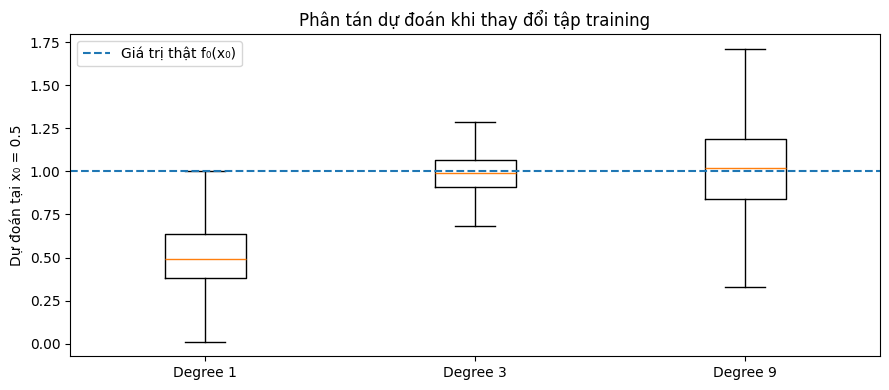

In [2]:
rng_bv = np.random.default_rng(120)
n_train, trials, x0, noise_sd = 16, 450, 0.5, 0.25
f_true = lambda x: np.sin(np.pi * x)
true_y = float(f_true(x0))
degrees = [1, 3, 9]
predictions = {}

for degree in degrees:
    preds = []
    for _ in range(trials):
        xs = rng_bv.uniform(-1, 1, n_train)
        ys = f_true(xs) + rng_bv.normal(0, noise_sd, n_train)
        # fit polynomial using least squares; ignore possible rank warnings for this toy experiment
        Xmat = np.polynomial.polynomial.polyvander(xs, degree)
        coeffs = np.linalg.lstsq(Xmat, ys, rcond=None)[0]
        x0_features = np.polynomial.polynomial.polyvander([x0], degree)
        preds.append(float((x0_features @ coeffs)[0]))
    predictions[degree] = np.array(preds)

print(f"Hàm thật f₀({x0}) = {true_y:.4f}; noise variance = {noise_sd**2:.4f}\n")
print("Degree  Bias²      Variance   Noise     Tổng lý thuyết (ước lượng MC)")
for degree in degrees:
    pred = predictions[degree]
    bias2 = (pred.mean() - true_y)**2
    variance = pred.var(ddof=0)
    print(f"{degree:<7} {bias2:8.4f}   {variance:8.4f}  {noise_sd**2:8.4f}  {bias2+variance+noise_sd**2:8.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([predictions[d] for d in degrees], tick_labels=[f"Degree {d}" for d in degrees], showfliers=False)
ax.axhline(true_y, linestyle='--', label='Giá trị thật f₀(x₀)')
ax.set_ylabel('Dự đoán tại x₀ = 0.5')
ax.set_title('Phân tán dự đoán khi thay đổi tập training')
ax.legend()
plt.tight_layout()
plt.show()

### 1.7. Kiểm tra đẳng thức trực tiếp bằng Monte Carlo

Ta sinh một nhiễu test mới **độc lập** cho mỗi giá trị dự đoán. Hai vế phải gần nhau khi số lần mô phỏng lớn.

In [3]:
rng_check = np.random.default_rng(2026)
for degree in degrees:
    pred = predictions[degree]
    test_noise = rng_check.normal(0, noise_sd, size=len(pred))
    left = np.mean((true_y + test_noise - pred)**2)
    right = noise_sd**2 + (pred.mean()-true_y)**2 + pred.var(ddof=0)
    print(f"Bậc {degree}: E[(Y-f̂)²] ≈ {left:.4f}; Noise + Bias² + Variance ≈ {right:.4f}")

Bậc 1: E[(Y-f̂)²] ≈ 0.3702; Noise + Bias² + Variance ≈ 0.3488
Bậc 3: E[(Y-f̂)²] ≈ 0.0887; Noise + Bias² + Variance ≈ 0.0799
Bậc 9: E[(Y-f̂)²] ≈ 205.9213; Noise + Bias² + Variance ≈ 206.0919


### 1.8. Trả lời phần Interpretation

Mô hình càng linh hoạt (ví dụ bậc đa thức càng lớn) thì càng có khả năng khớp nhiều dao động trong tập training. Vì thế **training error thường giảm**; tuy nhiên, nó cũng có thể học cả nhiễu ngẫu nhiên. Khi tập training thay đổi, các hệ số và dự đoán có thể biến động mạnh (**variance tăng**), khiến **prediction error** trên dữ liệu mới tăng.

**Một câu trả lời tiếng Anh ngắn:** *A more flexible model can fit training noise and achieve lower training error, but become sensitive to the particular sample. Its variance may increase enough to outweigh its reduction in bias, resulting in larger prediction error.*

---
# 2. Trang 36 — K-fold Cross-validation: bao nhiêu folds?

Trang 36 là phần lý thuyết bổ sung (không có Additional Exercise riêng). Với $n$ quan sát và $K$ folds:

- Mỗi lượt học trên khoảng $n(K-1)/K$ quan sát, đánh giá trên khoảng $n/K$ quan sát.
- $K=5$ hoặc $K=10$ được dùng phổ biến.
- $K=n$ là **Leave-One-Out CV**: học trên $n-1$ quan sát nhưng phải fit $n$ lần.
- Không có $K$ tối ưu cho mọi bài toán: cần cân bằng dữ liệu huấn luyện, biến động của CV và chi phí tính toán.

**Ví dụ bổ sung:** với $n=100$, so sánh $K=5$, $K=10$ và $K=100$.

In [4]:
n = 100
for K in [5, 10, 100]:
    print(f"K={K:3}: train/fold={n-n//K:3}, validation/fold={n//K:2}, số lượt fit={K}")

K=  5: train/fold= 80, validation/fold=20, số lượt fit=5
K= 10: train/fold= 90, validation/fold=10, số lượt fit=10
K=100: train/fold= 99, validation/fold= 1, số lượt fit=100


---
# 3. Trang 37 — Soft Thresholding by Hand (Lasso)

### 3.1. Phân tích đề

Cho $\lambda\geq 0$ và $z$ cố định. Tìm:

$$\hat\beta=\underset{\beta\in\mathbb R}{\operatorname{argmin}}\ Q(\beta),\qquad Q(\beta)=\frac12(\beta-z)^2+\lambda|\beta|.$$

**Điểm dễ sai:** $|\beta|$ phải tách theo dấu của $\beta$; tại $\beta=0$ không thể tùy tiện lấy đạo hàm như hàm trơn (khi $\lambda>0$).

### 3.2. Trường hợp $\beta>0$

Vì $|\beta|=\beta$:

$$Q'(\beta)=\beta-z+\lambda=0\quad\Rightarrow\quad\boxed{\hat\beta=z-\lambda}.$$

Để nghiệm thuộc miền đang xét, cần $z-\lambda>0$, tức là **$z>\lambda$**.

### 3.3. Trường hợp $\beta<0$

Vì $|\beta|=-\beta$:

$$Q'(\beta)=\beta-z-\lambda=0\quad\Rightarrow\quad\boxed{\hat\beta=z+\lambda}.$$

Để nghiệm thuộc miền này, cần $z+\lambda<0$, tức là **$z<-\lambda$**.

### 3.4. Trường hợp $\beta=0$

Tại $0$, đạo hàm một phía:

$$Q'_-(0)=-z-\lambda,\qquad Q'_+(0)=-z+\lambda.$$

Điểm $0$ là cực tiểu khi **độ dốc bên trái $\leq0$ và độ dốc bên phải $\geq0$**:

$$-z-\lambda\leq0\quad\text{và}\quad -z+\lambda\geq0
\iff -\lambda\leq z\leq\lambda.$$

Cách viết tương đương bằng **subgradient**: $0\in -z+\lambda[-1,1]$.

### 3.5. Kết luận

$$\boxed{\hat\beta=
\begin{cases}
z-\lambda & z>\lambda,\\
0 & |z|\leq\lambda,\\
z+\lambda & z<-\lambda.
\end{cases}}$$

Hay dạng rút gọn:

$$\boxed{\hat\beta=\operatorname{sign}(z)(|z|-\lambda)_+,\quad (a)_+=\max(a,0).}$$

Vì có một **khoảng đầu vào được biến thành đúng 0**, Lasso có khả năng chọn biến (sparsity).

### 3.6. Kiểm tra các trường hợp bằng code

Chọn $\lambda=1$: $z=3$ cho nghiệm dương, $z=-3$ cho nghiệm âm, còn $z=0.7$ cho nghiệm đúng bằng 0. Dùng thêm tối ưu số để đối chiếu với công thức đã chứng minh.

In [5]:
def soft_threshold(z, lam):
    return np.sign(z) * np.maximum(np.abs(z)-lam, 0.)

def Q_lasso(beta, z, lam):
    return 0.5*(beta-z)**2 + lam*np.abs(beta)

for z in [3.0, -3.0, 0.7, -1.0]:
    lam = 1.0
    analytic = float(soft_threshold(z, lam))
    numeric = minimize_scalar(lambda b: Q_lasso(b,z,lam), bounds=(-10,10), method='bounded', options={'xatol':1e-12}).x
    print(f"z={z:5.1f}, λ={lam:.1f}: công thức β̂={analytic:7.4f}; tối ưu số ≈{numeric:7.4f}")
    assert abs(analytic-numeric) < 2e-4

z=  3.0, λ=1.0: công thức β̂= 2.0000; tối ưu số ≈ 2.0000
z= -3.0, λ=1.0: công thức β̂=-2.0000; tối ưu số ≈-2.0000
z=  0.7, λ=1.0: công thức β̂= 0.0000; tối ưu số ≈ 0.0000
z= -1.0, λ=1.0: công thức β̂=-0.0000; tối ưu số ≈-0.0000


### 3.7. Trực quan hóa (thử thay các giá trị $z$ và $\lambda$ trong code)

Đường dọc nét đứt đánh dấu nghiệm soft thresholding. Độ lớn $\lambda$ càng tăng, nghiệm càng bị kéo về 0.

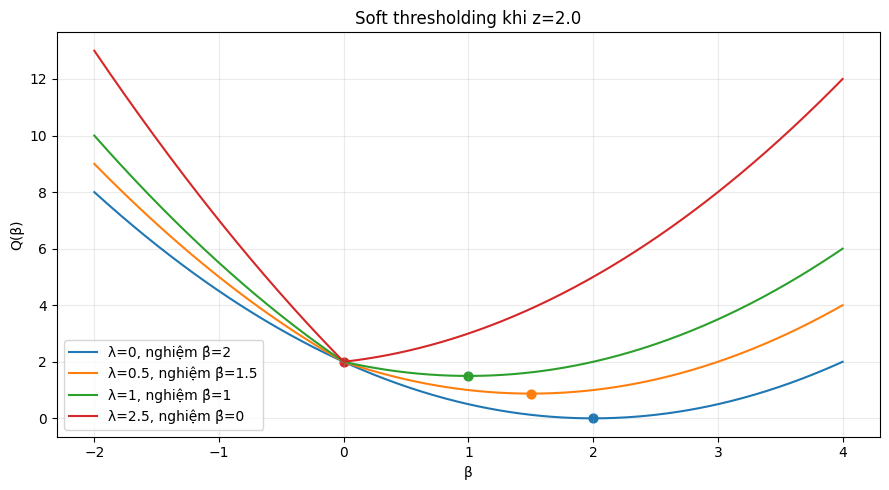

In [6]:
z = 2.0        # Thử đổi thành 0.6 hoặc -2.0
lambdas = [0, 0.5, 1, 2.5]
betas = np.linspace(-2, 4, 500)
plt.figure(figsize=(9,5))
for lam in lambdas:
    q = Q_lasso(betas,z,lam)
    sol = soft_threshold(z,lam)
    plt.plot(betas, q, label=f"λ={lam}, nghiệm β̂={sol:g}")
    plt.scatter([sol],[Q_lasso(sol,z,lam)],s=40)
plt.xlabel('β')
plt.ylabel('Q(β)')
plt.title(f'Soft thresholding khi z={z}')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

---
# 4. Trang 38 — Ridge as a Gaussian MAP Estimator

### 4.1. Mô hình và yêu cầu

Slide cho mô hình **không có intercept**:

$$Y_i=\beta x_i+\varepsilon_i,\qquad \varepsilon_i\overset{\mathrm{iid}}{\sim}N(0,\sigma^2),$$

và Gaussian prior:

$$\beta\sim N(0,\tau^2).$$

Yêu cầu: (1) viết negative log-posterior (bỏ hằng số); (2) chứng minh công thức MAP; (3) xét hai giới hạn $\tau^2\to\infty$ và $\tau^2\to0$.

### 4.2. Bước 1 — Viết likelihood

$$p(y\mid x,\beta)\propto\exp\!\left[-\frac{1}{2\sigma^2}\sum_i(y_i-\beta x_i)^2\right].$$

### 4.3. Bước 2 — Viết prior

$$p(\beta)\propto\exp\!\left[-\frac{\beta^2}{2\tau^2}\right].$$

### 4.4. Bước 3 — Áp dụng Bayes, lấy negative log

$$p(\beta\mid D)\propto p(y\mid x,\beta)p(\beta).$$

Bỏ các số hạng **không phụ thuộc vào $\beta$**:

$$\boxed{-\log p(\beta\mid D)=\frac{1}{2\sigma^2}\sum_i(y_i-\beta x_i)^2+\frac{1}{2\tau^2}\beta^2+\mathrm{constant}.}$$

Nhân với $2\sigma^2>0$, việc tìm cực tiểu không đổi:

$$\hat\beta_{\mathrm{MAP}}=\arg\min_\beta\Big\{\sum_i(y_i-\beta x_i)^2+\underbrace{\frac{\sigma^2}{\tau^2}}_{\lambda}\beta^2\Big\}.$$

**Kết nối với Ridge:** trong cách viết dùng **tổng** bình phương sai số của slide này, $\boxed{\lambda=\sigma^2/\tau^2}$. Nếu dùng **trung bình** bình phương sai số hoặc thêm hệ số $1/2$ trong hàm mục tiêu, hệ số penalty phải đổi theo quy ước đó.

### 4.5. Bước 4 — Lấy đạo hàm và giải

$$\begin{aligned}
0&=\frac{\partial}{\partial\beta}\left[\sum_i(y_i-\beta x_i)^2+\frac{\sigma^2}{\tau^2}\beta^2\right]\\
&=-2\sum_i x_i(y_i-\beta x_i)+2\frac{\sigma^2}{\tau^2}\beta.
\end{aligned}$$

Đặt các hạng chứa $\beta$ về một phía:

$$\beta\left(\sum_i x_i^2+\frac{\sigma^2}{\tau^2}\right)=\sum_i x_i y_i.$$

Suy ra:

$$\boxed{\hat\beta_{\mathrm{MAP}}=\frac{\sum_i x_i y_i}{\sum_i x_i^2+\sigma^2/\tau^2}.}$$

Đạo hàm bậc hai bằng $2(\sum_i x_i^2+\sigma^2/\tau^2)>0$, nên đây là nghiệm cực tiểu duy nhất khi $\sigma^2,\tau^2>0$.

### 4.6. Bước 5 — Hai giới hạn

- $\tau^2\to\infty$ ⇒ prior yếu ⇒ $\lambda\to0$ ⇒ $\hat\beta_{\mathrm{MAP}}\to \sum_i x_i y_i/\sum_i x_i^2$ (OLS, nếu mẫu số dương).
- $\tau^2\to0^+$ ⇒ prior ép $\beta$ gần 0 ⇒ $\lambda\to\infty$ ⇒ $\hat\beta_{\mathrm{MAP}}\to0$.

### 4.7. Thí nghiệm số minh họa Ridge–MAP

Ví dụ tự tạo: $x=[1,2,3,4]$, $y=[1.1,1.9,3.2,3.9]$, $\sigma^2=1$. Cho các giá trị prior variance $\tau^2$ giảm dần và quan sát $\hat\beta_{\mathrm{MAP}}$ bị co về 0.

In [7]:
x = np.array([1.,2.,3.,4.])
y = np.array([1.1,1.9,3.2,3.9])
sigma2 = 1.0
Sxx, Sxy = np.sum(x*x), np.sum(x*y)
print(f"Sxx={Sxx:.4f}, Sxy={Sxy:.4f}, OLS={Sxy/Sxx:.4f}\n")

prior_variances = [100, 2, 0.5, 0.05]
for tau2 in prior_variances:
    lam = sigma2/tau2
    beta_map = Sxy/(Sxx+lam)
    solution = minimize_scalar(lambda b: np.sum((y-b*x)**2)+lam*b*b,
                               bounds=(-10,10),method='bounded').x
    print(f"τ²={tau2:7.3f}, λ={lam:7.3f}: β̂_MAP={beta_map:.5f}, số={solution:.5f}")
    assert np.isclose(beta_map,solution,atol=1e-6)

Sxx=30.0000, Sxy=30.1000, OLS=1.0033

τ²=100.000, λ=  0.010: β̂_MAP=1.00300, số=1.00300
τ²=  2.000, λ=  0.500: β̂_MAP=0.98689, số=0.98689
τ²=  0.500, λ=  2.000: β̂_MAP=0.94063, số=0.94062
τ²=  0.050, λ= 20.000: β̂_MAP=0.60200, số=0.60200


### 4.8. Bổ sung để hiểu sâu: posterior cũng là Gaussian

Không bắt buộc cho bài trang 38, nhưng từ bước **hoàn thành bình phương** ta còn suy ra:

$$\beta\mid D\sim N(m_n,v_n),\quad
v_n=\frac{1}{S_{xx}/\sigma^2+1/\tau^2},\quad
m_n=v_n\frac{S_{xy}}{\sigma^2}.$$

Phân phối Gaussian có mean trùng mode, nên $m_n=\hat\beta_{\mathrm{MAP}}$. Đường posterior càng hẹp khi có nhiều dữ liệu có thông tin hoặc prior càng mạnh.

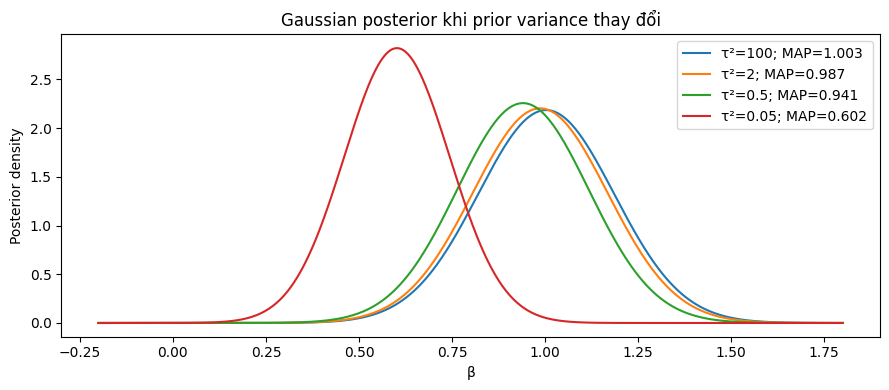

In [8]:
from scipy.stats import norm
bgrid = np.linspace(-0.2, 1.8, 600)
fig, ax = plt.subplots(figsize=(9,4))
for tau2 in [100, 2, 0.5, 0.05]:
    vn = 1/(Sxx/sigma2+1/tau2)
    mn = vn*Sxy/sigma2
    ax.plot(bgrid, norm.pdf(bgrid,mn,np.sqrt(vn)),label=f"τ²={tau2}; MAP={mn:.3f}")
ax.set_title('Gaussian posterior khi prior variance thay đổi')
ax.set_xlabel('β')
ax.set_ylabel('Posterior density')
ax.legend()
plt.tight_layout()
plt.show()

---
# 5. Trang 39 — Regularizing Separated Logistic Data

### 5.1. Hiểu vấn đề

Slide cho log-likelihood của một ví dụ dữ liệu **phân tách hoàn hảo**:

$$\ell(\beta)=2\log s(\beta)+2\log s(2\beta),\quad s(t)=\frac{1}{1+e^{-t}}.$$

Ở đây viết sigmoid là $s(t)$ cho dễ phân biệt với phương sai $\sigma^2$ ở bài trước; trên slide sigmoid ký hiệu $\sigma(t)$.

Thêm ridge penalty ($\lambda>0$):

$$Q_\lambda(\beta)=\ell(\beta)-\frac{\lambda}{2}\beta^2.$$

Vì đây là **maximization** của log-likelihood, penalty được **trừ đi** (khác với các bài minimization trước, nơi penalty được cộng vào).

### 5.2. Bước 1 — Đạo hàm sigmoid và log-sigmoid

$$s'(t)=s(t)[1-s(t)],\qquad \frac{d}{dt}\log s(t)=1-s(t).$$

Áp dụng quy tắc dây chuyền:

$$\ell'(\beta)=2[1-s(\beta)]+4[1-s(2\beta)].$$

$$Q_\lambda'(\beta)=2[1-s(\beta)]+4[1-s(2\beta)]-\lambda\beta.$$

**Điểm dừng $Q_\lambda'(\beta)=0$ thỏa mãn chính xác điều đề yêu cầu:**

$$\boxed{2[1-s(\beta)]+4[1-s(2\beta)]-\lambda\beta=0.}$$

### 5.3. Bước 2 — Vì sao maximum hữu hạn?

**Khi không có penalty:** với mọi $\beta$ hữu hạn, $\ell'(\beta)>0$; $\ell(\beta)\uparrow0$ khi $\beta\to+\infty$. Do đó likelihood tiếp tục cải thiện khi đưa $\beta$ ra vô hạn, **không có MLE hữu hạn**.

**Khi $\lambda>0$:** $\ell(\beta)\leq0$ nên

$$Q_\lambda(\beta)\leq-\frac{\lambda}{2}\beta^2\to-\infty\quad\text{khi }|\beta|\to\infty.$$

Hàm liên tục và đi xuống $-\infty$ ở cả hai đầu, nên nó phải đạt cực đại tại một $\beta$ hữu hạn.

Ngoài ra:

$$Q_\lambda''(\beta)=-2s(\beta)[1-s(\beta)]-8s(2\beta)[1-s(2\beta)]-\lambda<0.$$

Vì hàm **lõm nghiêm ngặt**, nghiệm cực đại hữu hạn là **duy nhất**.

### 5.4. Bước 3 — Khi $\lambda$ tăng thì $\hat\beta$ ra sao?

Đặt $g(\beta)=2[1-s(\beta)]+4[1-s(2\beta)]$. Phương trình điểm dừng là $g(\beta)=\lambda\beta$.

- $g(\beta)>0$ và giảm nghiêm ngặt theo $\beta$.
- $\lambda\beta$ tăng theo $\beta$ và dốc hơn nếu tăng $\lambda$.
- Vì vậy, nghiệm dương duy nhất **giảm về 0 khi $\lambda$ tăng**.
- Khi $\lambda\to0^+$, $\hat\beta$ tăng không bị chặn: trở lại hiện tượng perfect separation.

### 5.5. Tính nghiệm số cho nhiều mức regularization

Phương trình điểm dừng thường không có nghiệm dạng đóng đơn giản. Dùng `brentq` để tìm nghiệm duy nhất trên khoảng $(0,\infty)$, với hàm sigmoid ổn định số học `scipy.special.expit`.

In [9]:
from scipy.special import expit

def ell(beta):
    # logaddexp tránh tràn số khi β có độ lớn lớn
    return -2*np.logaddexp(0.,-beta)-2*np.logaddexp(0.,-2*beta)

def Q_logistic(beta,lam):
    return ell(beta)-0.5*lam*beta*beta

def grad_Q(beta,lam):
    return 2*(1-expit(beta))+4*(1-expit(2*beta))-lam*beta

def hess_Q(beta,lam):
    p1,p2=expit(beta),expit(2*beta)
    return -2*p1*(1-p1)-8*p2*(1-p2)-lam

def find_beta(lam):
    assert lam>0
    # grad_Q(0)>0, còn grad_Q(large)<0
    hi=1.
    while grad_Q(hi,lam)>0:
        hi*=2
    return brentq(lambda b:grad_Q(b,lam),0,hi)

lambdas=[0.01,0.1,1,10,100]
sols=[]
print('   λ       β̂       Q(β̂)      Q\'(β̂)    Q\'\'(β̂)')
for lam in lambdas:
    beta=find_beta(lam)
    sols.append(beta)
    print(f'{lam:6.2f}  {beta:8.5f}  {Q_logistic(beta,lam):9.5f}  {grad_Q(beta,lam):10.2e}  {hess_Q(beta,lam):9.5f}')
    assert abs(grad_Q(beta,lam))<1e-8
    assert hess_Q(beta,lam)<0
assert all(sols[i]>sols[i+1] for i in range(len(sols)-1))
print('✓ Đạo hàm tại điểm dừng ≈ 0; độ cong âm; β̂ giảm khi λ tăng.')

   λ       β̂       Q(β̂)      Q'(β̂)    Q''(β̂)
  0.01   3.94530   -0.11690    6.94e-16   -0.05023
  0.10   2.27715   -0.47550    3.89e-16   -0.35119
  1.00   1.00659   -1.38033   -1.33e-15   -2.22356
 10.00   0.24077   -2.41201   -2.10e-13  -12.38122
100.00   0.02927   -2.72869    5.77e-15  -102.49818
✓ Đạo hàm tại điểm dừng ≈ 0; độ cong âm; β̂ giảm khi λ tăng.


### 5.6. Vẽ các hàm $Q_\lambda(\beta)$

Quan sát vị trí cực đại: penalty càng mạnh thì nghiệm càng gần 0.

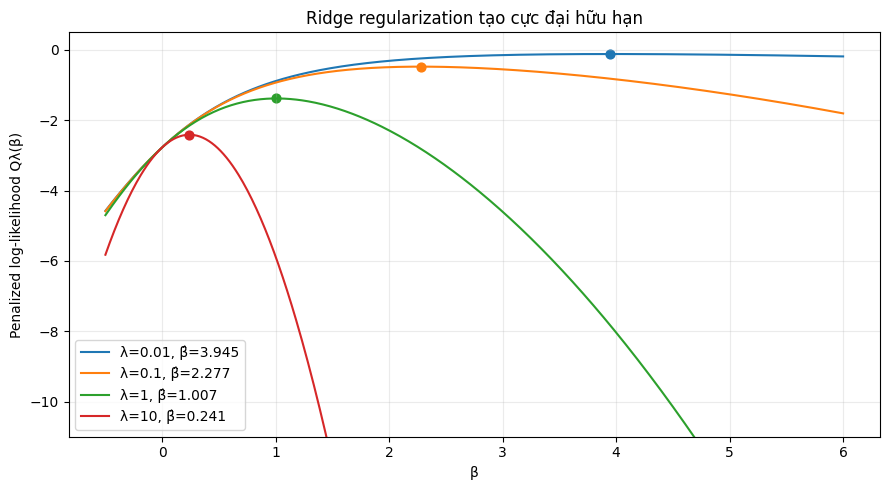

In [10]:
betas=np.linspace(-0.5,6,500)
fig,ax=plt.subplots(figsize=(9,5))
for lam in [0.01,0.1,1,10]:
    vals=np.array([Q_logistic(b,lam) for b in betas])
    bhat=find_beta(lam)
    ax.plot(betas,vals,label=f'λ={lam:g}, β̂={bhat:.3f}')
    ax.scatter([bhat],[Q_logistic(bhat,lam)],s=40)
ax.set_xlabel('β')
ax.set_ylabel('Penalized log-likelihood Qλ(β)')
ax.set_title('Ridge regularization tạo cực đại hữu hạn')
ax.set_ylim(-11,0.5)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

---
# 6. Tổng kết để ôn thi

| Trang | Cần nhớ | Kết luận |
|---|---|---|
| **35** | Bình phương 3 số hạng; kỳ vọng tích chéo bằng 0 | $E[\text{test error}^2]=\sigma^2+\text{Bias}^2+\text{Variance}$ |
| **36** | CV chỉ dùng training folds; xoay vòng validation folds | $K=5$ hoặc $10$ thường được dùng; không có $K$ luôn tối ưu |
| **37** | Tách $\beta>0$, $\beta<0$, $\beta=0$ | Lasso soft threshold: $\hat\beta=\operatorname{sign}(z)(|z|-\lambda)_+$ |
| **38** | Posterior $\propto$ likelihood × prior | Gaussian prior tạo penalty $L_2$; $\lambda=\sigma^2/\tau^2$ theo quy ước slide |
| **39** | $\frac{d}{dt}\log s(t)=1-s(t)$ | Ridge chống nghiệm logistic chạy ra vô hạn khi perfect separation |

**Mẹo khi làm bài tự luận:**

1. Viết rõ **đại lượng nào đang được cố định** và **lấy kỳ vọng theo nguồn ngẫu nhiên nào**.
2. Nếu gặp $|\beta|$, nhớ tách miền và xử lý điểm $0$.
3. Với MAP, viết `likelihood → prior → posterior → negative log → đạo hàm`.
4. Với Logistic Regression, phân biệt **maximizing penalized log-likelihood** với **minimizing negative log-likelihood + penalty**.

### Tự luyện thêm (không có trong slide)

- Trang 35: Nếu $\sigma^2=0.1$, Bias $=0.3$ và Variance $=0.4$, prediction MSE bằng bao nhiêu?
- Trang 37: Tính nghiệm với $(z,\lambda)=(1.2,0.5)$, $(-0.3,0.5)$, $(-2,0.5)$.
- Trang 38: Thay $\tau^2=\sigma^2$ và $S_{xx}=4$, $S_{xy}=6$ vào công thức MAP.
- Trang 39: Nếu tăng $\lambda$ từ $0.1$ lên $10$, chiều thay đổi của $\hat\beta$ là gì và vì sao?

In [11]:
# Kiểm tra nhanh 4 bài tự luyện
print('Trang 35:', 0.1+0.3**2+0.4)
print('Trang 37:', [soft_threshold(z,0.5) for z in [1.2,-0.3,-2]])
print('Trang 38:', 6/(4+1))
print('Trang 39: β̂(λ=0.1) =',round(find_beta(0.1),4),'> β̂(λ=10) =',round(find_beta(10),4))

Trang 35: 0.5900000000000001
Trang 37: [np.float64(0.7), np.float64(-0.0), np.float64(-1.5)]
Trang 38: 1.2
Trang 39: β̂(λ=0.1) = 2.2772 > β̂(λ=10) = 0.2408
